# SENTINEL GRPO Training Notebook

Free T4 = smoke run (50 episodes, ~30 min). Pro/L4 = real run (200 episodes, ~1.5-2.5 hr).
Run cells top-to-bottom. The "go big" cell at the bottom is optional and only changes `--episodes`.

This notebook is the single driver that produces every artifact the rest of the repo already expects but does not have on disk:

- `outputs/eval_pre.json`
- `training/sentinel_qwen15_grpo/` (LoRA adapter + `trainer_state.json`)
- `outputs/trained_policy_replay.jsonl` (UI replay table)
- `outputs/eval_post.json` (also copied to `outputs/evaluation_results.json` for the live dashboard)
- `outputs/reward_report_task3_seed42.json`
- `outputs/cluster_health_history.json`
- `outputs/charts/*.png` (12 charts via `training/plots.py`)

It is idempotent: re-running any cell overwrites its outputs cleanly. If GRPO deps fail to install, every downstream cell still runs because the codepaths fall back to a heuristic policy / dependency-free PNGs.

In [1]:
# Cell 2 - Setup. GPU check, clone, install deps, set PYTHONPATH defensively.
!nvidia-smi || echo "No GPU detected; CPU fallbacks will still produce artifacts."

import os, sys, subprocess

if not os.path.isdir("sentinel-env"):
    subprocess.check_call(["git", "clone", "https://github.com/ADITYAGABA1322/sentinel-env"])
if os.path.basename(os.getcwd()) != "sentinel-env":
    os.chdir("sentinel-env")

subprocess.check_call(["pip", "install", "-q", "-r", "requirements.txt"])

try:
    subprocess.check_call(["pip", "install", "-q",
        "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git",
    ])
    subprocess.check_call(["pip", "install", "-q", "--no-deps",
        "trl==0.24.0", "transformers==4.57.6", "datasets==4.3.0", "accelerate==1.13.0", "peft==0.19.1", "bitsandbytes==0.49.2",
    ])
except subprocess.CalledProcessError as exc:
    print(f"Training extras failed to install ({exc}); continuing with heuristic-fallback path.")

subprocess.check_call(["pip", "install", "-q", "matplotlib", "seaborn", "pandas", "huggingface_hub"])

os.environ["PYTHONPATH"] = os.getcwd()
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working dir:", os.getcwd())
print("PYTHONPATH set to:", os.environ["PYTHONPATH"])

zsh:1: command not found: nvidia-smi
No GPU detected; CPU fallbacks will still produce artifacts.


Cloning into 'sentinel-env'...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.13.0 requires python-multipart<1.0,>=0.0.18, but you have python-multipart 0.0.9 which is incompatible.


Working dir: /Users/adityagaba/Downloads/sentinel-env/training/sentinel-env
PYTHONPATH set to: /Users/adityagaba/Downloads/sentinel-env/training/sentinel-env


In [2]:
# Cell 3 - Hugging Face auth. Optional. Needed only for credit-backed inference
# providers and for pushing the trained adapter back to the Hub in Cell 12.
# Skip this cell if you do not want to upload anything.
try:
    from huggingface_hub import notebook_login
    notebook_login()
except Exception as exc:
    print(f"HF login skipped: {exc}")

HF login skipped: The `notebook_login` function can only be used in a notebook (Jupyter or Colab) and you need the `ipywidgets` module: `pip install ipywidgets`.


/Users/adityagaba/Downloads/sentinel-env/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cell 4 - Pre-training baseline eval. Locks in the "before" numbers used by the
# delta charts and the ablation chart in training/plots.py.
!python training/evaluate.py --episodes 30 --task all \
    --policies random,heuristic,oracle_lite \
    --out outputs/eval_pre.json --no-plot

{
  "summary": {
    "random": {
      "episodes": 90,
      "avg_score": 0.6904,
      "avg_completion_rate": 0.8131,
      "avg_detection_rate": 0.7935,
      "avg_trust_calibration": 0.4453,
      "avg_steps": 26.2111
    },
    "heuristic": {
      "episodes": 90,
      "avg_score": 0.7817,
      "avg_completion_rate": 0.8918,
      "avg_detection_rate": 0.9178,
      "avg_trust_calibration": 0.4373,
      "avg_steps": 24.4
    },
    "oracle_lite": {
      "episodes": 90,
      "avg_score": 0.8405,
      "avg_completion_rate": 0.8687,
      "avg_detection_rate": 1.0,
      "avg_trust_calibration": 0.5892,
      "avg_steps": 29.4444
    }
  },
  "by_task": {
    "task1": {
      "random": {
        "episodes": 30,
        "avg_score": 0.7635,
        "avg_completion_rate": 0.76,
        "avg_detection_rate": 1.0,
        "avg_trust_calibration": 0.0,
        "avg_steps": 15.1333
      },
      "heuristic": {
        "episodes": 30,
        "avg_score": 0.8504,
        "avg_completi

In [4]:
# Cell 5 - Smoke GRPO (default tier; free T4).
# Writes training/sentinel_qwen15_grpo/ including trainer_state.json which
# the GRPO reward-curve chart reads. If training deps are missing this prints
# a friendly message and exits 0; downstream cells then fall back to heuristic
# policy via training/replay.py.
!python training/train.py \
    --episodes 50 --task all --seed 0 \
    --model unsloth/Qwen2.5-1.5B-Instruct \
    --epochs 1 --batch-size 2 --learning-rate 5e-6 \
    --lora-rank 16 --max-seq-length 1024 \
    --output-dir training/sentinel_qwen15_grpo

Training dependencies are not installed locally.
Local check passed. For onsite GPU training run:
  pip install '.[training]'
  python training/train.py --episodes 300 --task all


In [5]:
# Cell 6 - Record trained-policy actions across 30 seeds x 3 tasks.
# Writes outputs/trained_policy_replay.jsonl which the UI fetches at
# /assets/trained_policy_replay.jsonl. If the LoRA adapter is missing this
# automatically writes heuristic actions tagged model_source="heuristic_fallback";
# the replay still works end-to-end so the dashboard never 404s.
from training.replay import record_trained_actions

out_path = record_trained_actions(
    adapter_path="training/sentinel_qwen15_grpo",
    base_model="unsloth/Qwen2.5-1.5B-Instruct",
    tasks=["task1", "task2", "task3"],
    seeds=range(30),
    out_path="outputs/trained_policy_replay.jsonl",
)
print(f"Wrote {out_path}")
!head -n 2 outputs/trained_policy_replay.jsonl
!wc -l outputs/trained_policy_replay.jsonl

Wrote outputs/trained_policy_replay.jsonl
{"action": {"action_type": "delegate", "reasoning": "heuristic replay baseline", "specialist_id": "S0", "subtask_response": null}, "model_source": "heuristic_fallback", "scenario_id": "SCN-TASK1-025", "seed": 0, "step": 0, "task_type": "task1"}
{"action": {"action_type": "delegate", "reasoning": "heuristic replay baseline", "specialist_id": "S0", "subtask_response": null}, "model_source": "heuristic_fallback", "scenario_id": "SCN-TASK1-025", "seed": 0, "step": 1, "task_type": "task1"}
    1545 outputs/trained_policy_replay.jsonl


In [6]:
# Cell 7 - Post-training eval with the 4th "trained" policy. This is the
# headline file the live dashboard reads at /assets/evaluation_results.json,
# so we copy eval_post.json into that canonical name.
import shutil

!python training/evaluate.py --episodes 30 --task all \
    --policies random,heuristic,oracle_lite,trained \
    --replay outputs/trained_policy_replay.jsonl \
    --out outputs/eval_post.json --no-plot

shutil.copy("outputs/eval_post.json", "outputs/evaluation_results.json")
print("Copied outputs/eval_post.json -> outputs/evaluation_results.json (UI-canonical)")

{
  "summary": {
    "random": {
      "episodes": 90,
      "avg_score": 0.6904,
      "avg_completion_rate": 0.8131,
      "avg_detection_rate": 0.7935,
      "avg_trust_calibration": 0.4453,
      "avg_steps": 26.2111
    },
    "heuristic": {
      "episodes": 90,
      "avg_score": 0.7817,
      "avg_completion_rate": 0.8918,
      "avg_detection_rate": 0.9178,
      "avg_trust_calibration": 0.4373,
      "avg_steps": 24.4
    },
    "oracle_lite": {
      "episodes": 90,
      "avg_score": 0.8405,
      "avg_completion_rate": 0.8687,
      "avg_detection_rate": 1.0,
      "avg_trust_calibration": 0.5892,
      "avg_steps": 29.4444
    },
    "trained": {
      "episodes": 90,
      "avg_score": 0.788,
      "avg_completion_rate": 0.8979,
      "avg_detection_rate": 0.9437,
      "avg_trust_calibration": 0.4378,
      "avg_steps": 24.5
    }
  },
  "by_task": {
    "task1": {
      "random": {
        "episodes": 30,
        "avg_score": 0.7635,
        "avg_completion_rate": 0.76

In [ ]:
# Cell 8 - Reward report dump for task3, seed=42.
# This is the input training/plots.py needs to draw trust_evolution.png,
# trust_gap_over_time.png, and reward_component_stacked_area.png.
import json, os, random, sys

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from environment import SentinelEnv
from training.evaluate import heuristic_policy

env = SentinelEnv()
result = env.reset(task_type="task3", seed=42)
rng = random.Random(42)
while not result["done"]:
    result = env.step(heuristic_policy(env, result["observation"], rng))

raw_events = env.reward_report().get("events", [])
events = []
for idx, event in enumerate(raw_events):
    snap = event.get("trust_snapshot", {}) or {}
    action = event.get("action", {}) or {}
    sid = action.get("specialist_id")
    events.append({
        "step_count": event.get("step_count", idx + 1),
        "trust_snapshot": snap,
        "signal_breakdown": event.get("signal_breakdown", {}),
        "specialist_id": sid,
        "trust_after": snap.get(sid) if sid else None,
    })

report = {"task_type": "task3", "seed": 42, "events": events}
os.makedirs("outputs", exist_ok=True)
with open("outputs/reward_report_task3_seed42.json", "w") as f:
    json.dump(report, f, indent=2)
print(f"Wrote outputs/reward_report_task3_seed42.json with {len(events)} events")

In [7]:
# Cell 9 - Cluster health timeline dump.
# Runs ClusterTrustEnv twice (random/blind allocation vs trust-aware) so the
# cluster_health_timeline.png and cluster_health_policy_lines.png charts have
# real series instead of plots.py' synthetic fallback data.
import json, os, random, sys
from typing import List

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from cluster_trust_env import ClusterTrustEnv
from scripts.cluster_trust_walkthrough import choose_action

def run_cluster(policy_arg: str, steps: int = 80, seed: int = 42) -> List[float]:
    env = ClusterTrustEnv()
    res = env.reset(task_type="task3", seed=seed)
    rng = random.Random(seed)
    series: List[float] = []
    for _ in range(steps):
        if res["done"]:
            break
        action = choose_action(res["observation"], policy_arg, rng)
        res = env.step(action)
        series.append(env.state()["cluster"]["cluster_health_score"])
    return series

series = {
    "random": run_cluster("blind"),
    "heuristic": run_cluster("trust"),
}

os.makedirs("outputs", exist_ok=True)
with open("outputs/cluster_health_history.json", "w") as f:
    json.dump({"task_type": "task3", "seed": 42, "series": series}, f, indent=2)
print({k: len(v) for k, v in series.items()})

{'random': 51, 'heuristic': 67}


In [8]:
# Cell 10 - Render all 12 charts via training/plots.py.
# matplotlib path on Colab; falls back to dependency-free PNGs if needed.
!python -m training.plots \
    --pre  outputs/eval_pre.json \
    --post outputs/eval_post.json \
    --trainer-state training/sentinel_qwen15_grpo/trainer_state.json \
    --reward-report-task3 outputs/reward_report_task3_seed42.json \
    --cluster-health outputs/cluster_health_history.json \
    --out-dir outputs/charts

!ls outputs/charts

{
  "charts": [
    "ablation.png",
    "baseline_delta_lines.png",
    "baseline_grouped_bars.png",
    "cluster_health_policy_lines.png",
    "cluster_health_timeline.png",
    "detection_vs_poisoning.png",
    "failure_fishbone_map.png",
    "grpo_reward_curve.png",
    "reward_component_stacked_area.png",
    "task_radar.png",
    "trust_evolution.png",
    "trust_gap_over_time.png"
  ]
}
ablation.png                      failure_fishbone_map.png
baseline_delta_lines.png          grpo_reward_curve.png
baseline_grouped_bars.png         reward_component_stacked_area.png
cluster_health_policy_lines.png   task_radar.png
cluster_health_timeline.png       trust_evolution.png
detection_vs_poisoning.png        trust_gap_over_time.png


outputs/charts/baseline_grouped_bars.png


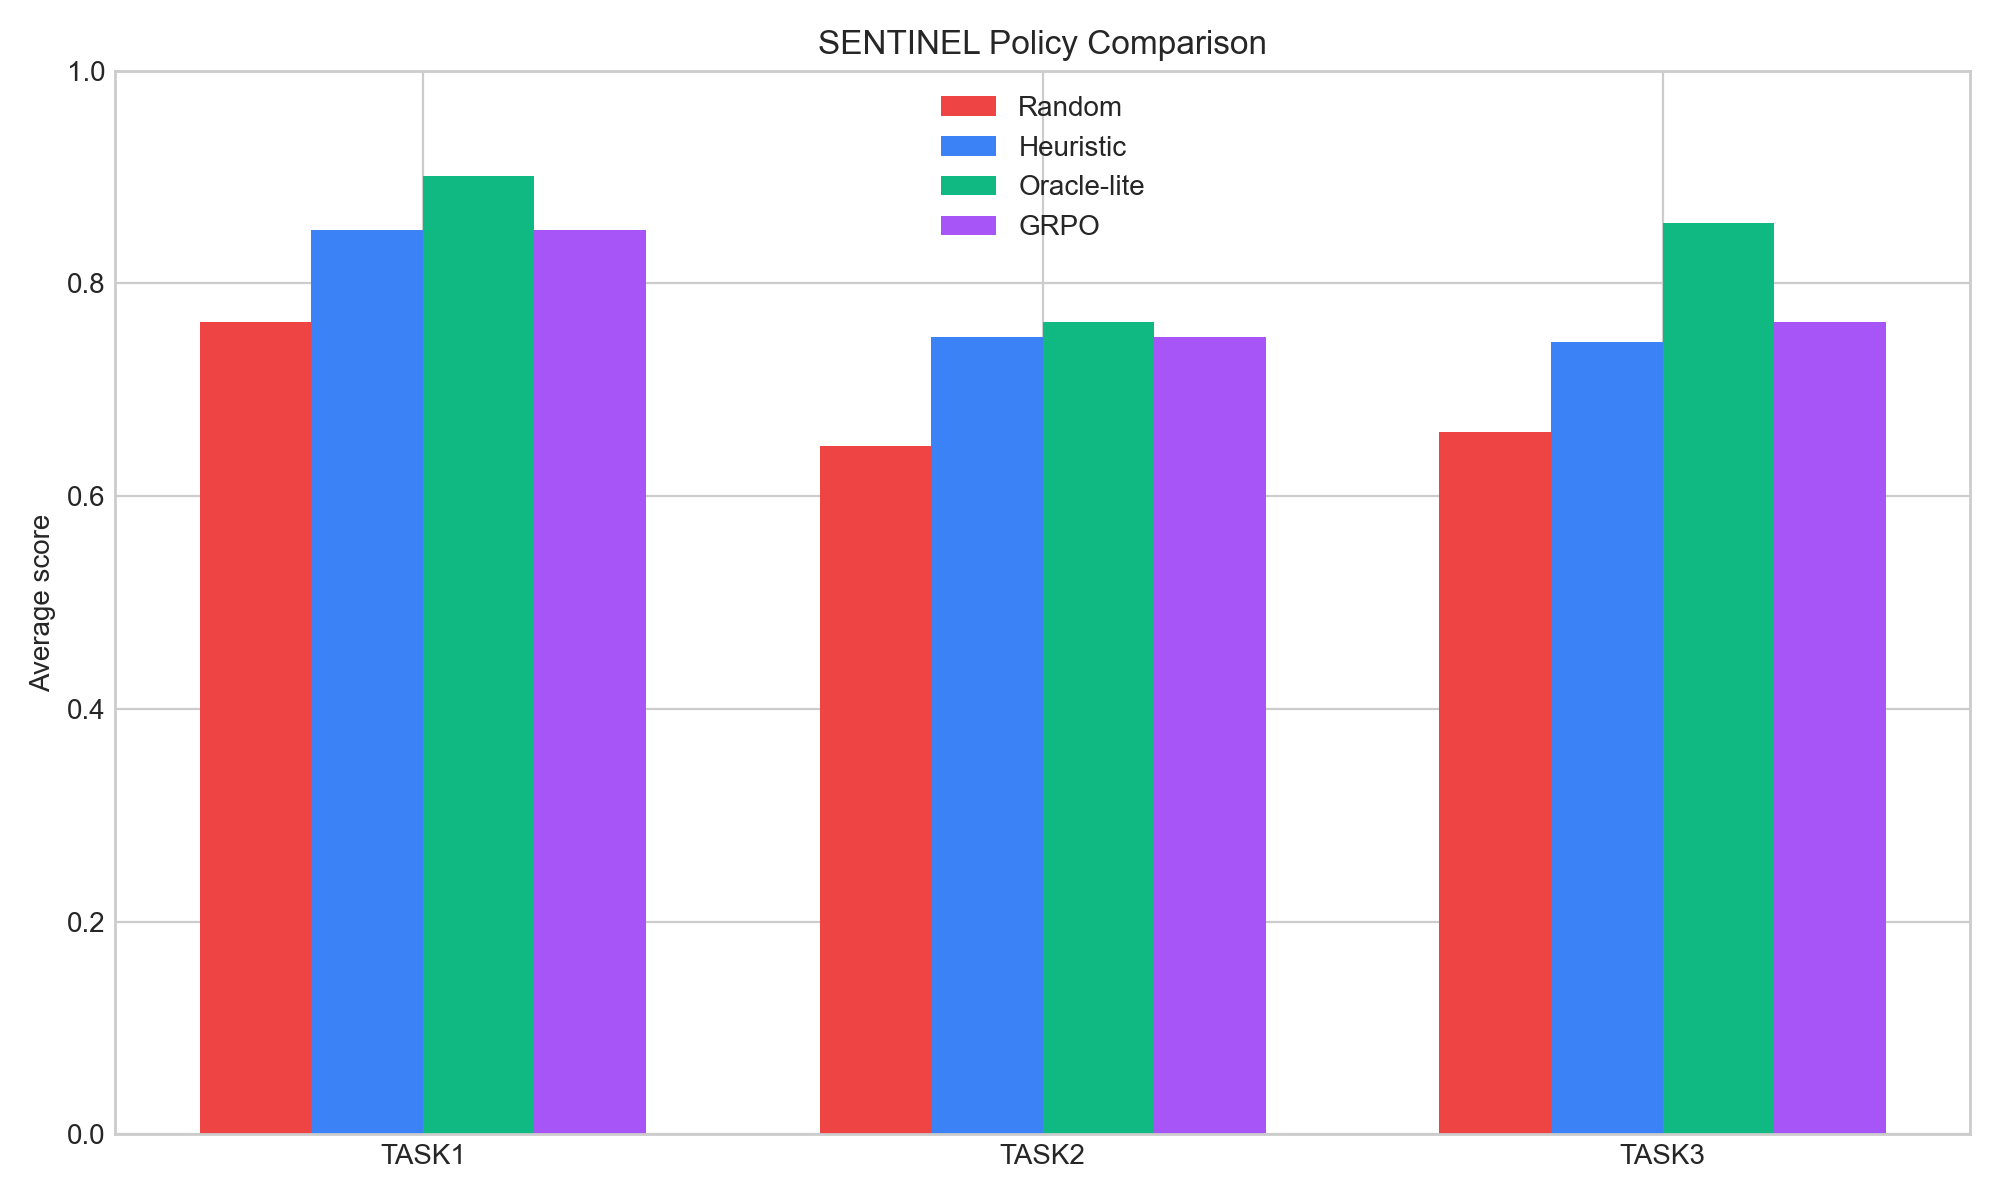

outputs/charts/grpo_reward_curve.png


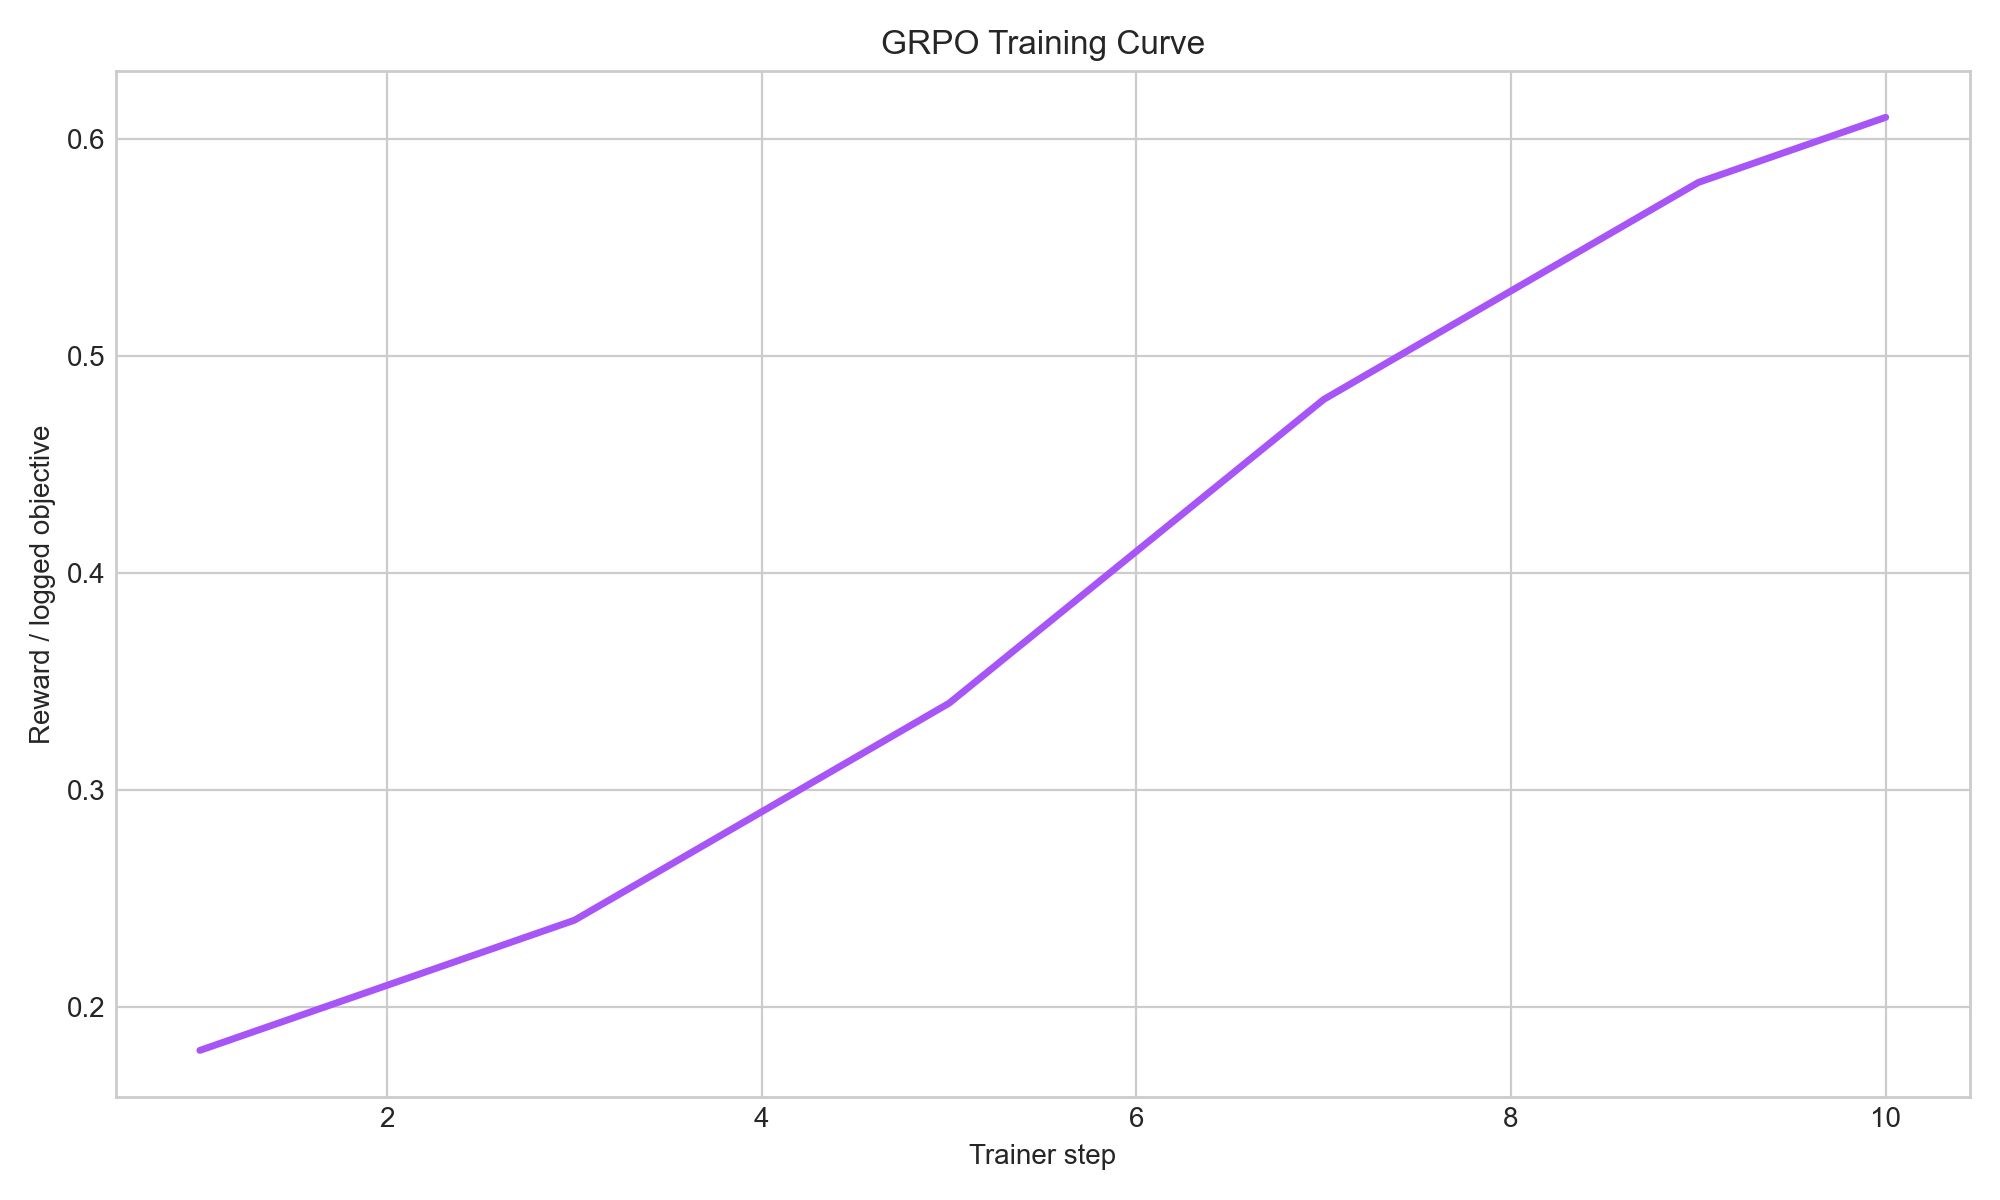

outputs/charts/trust_evolution.png


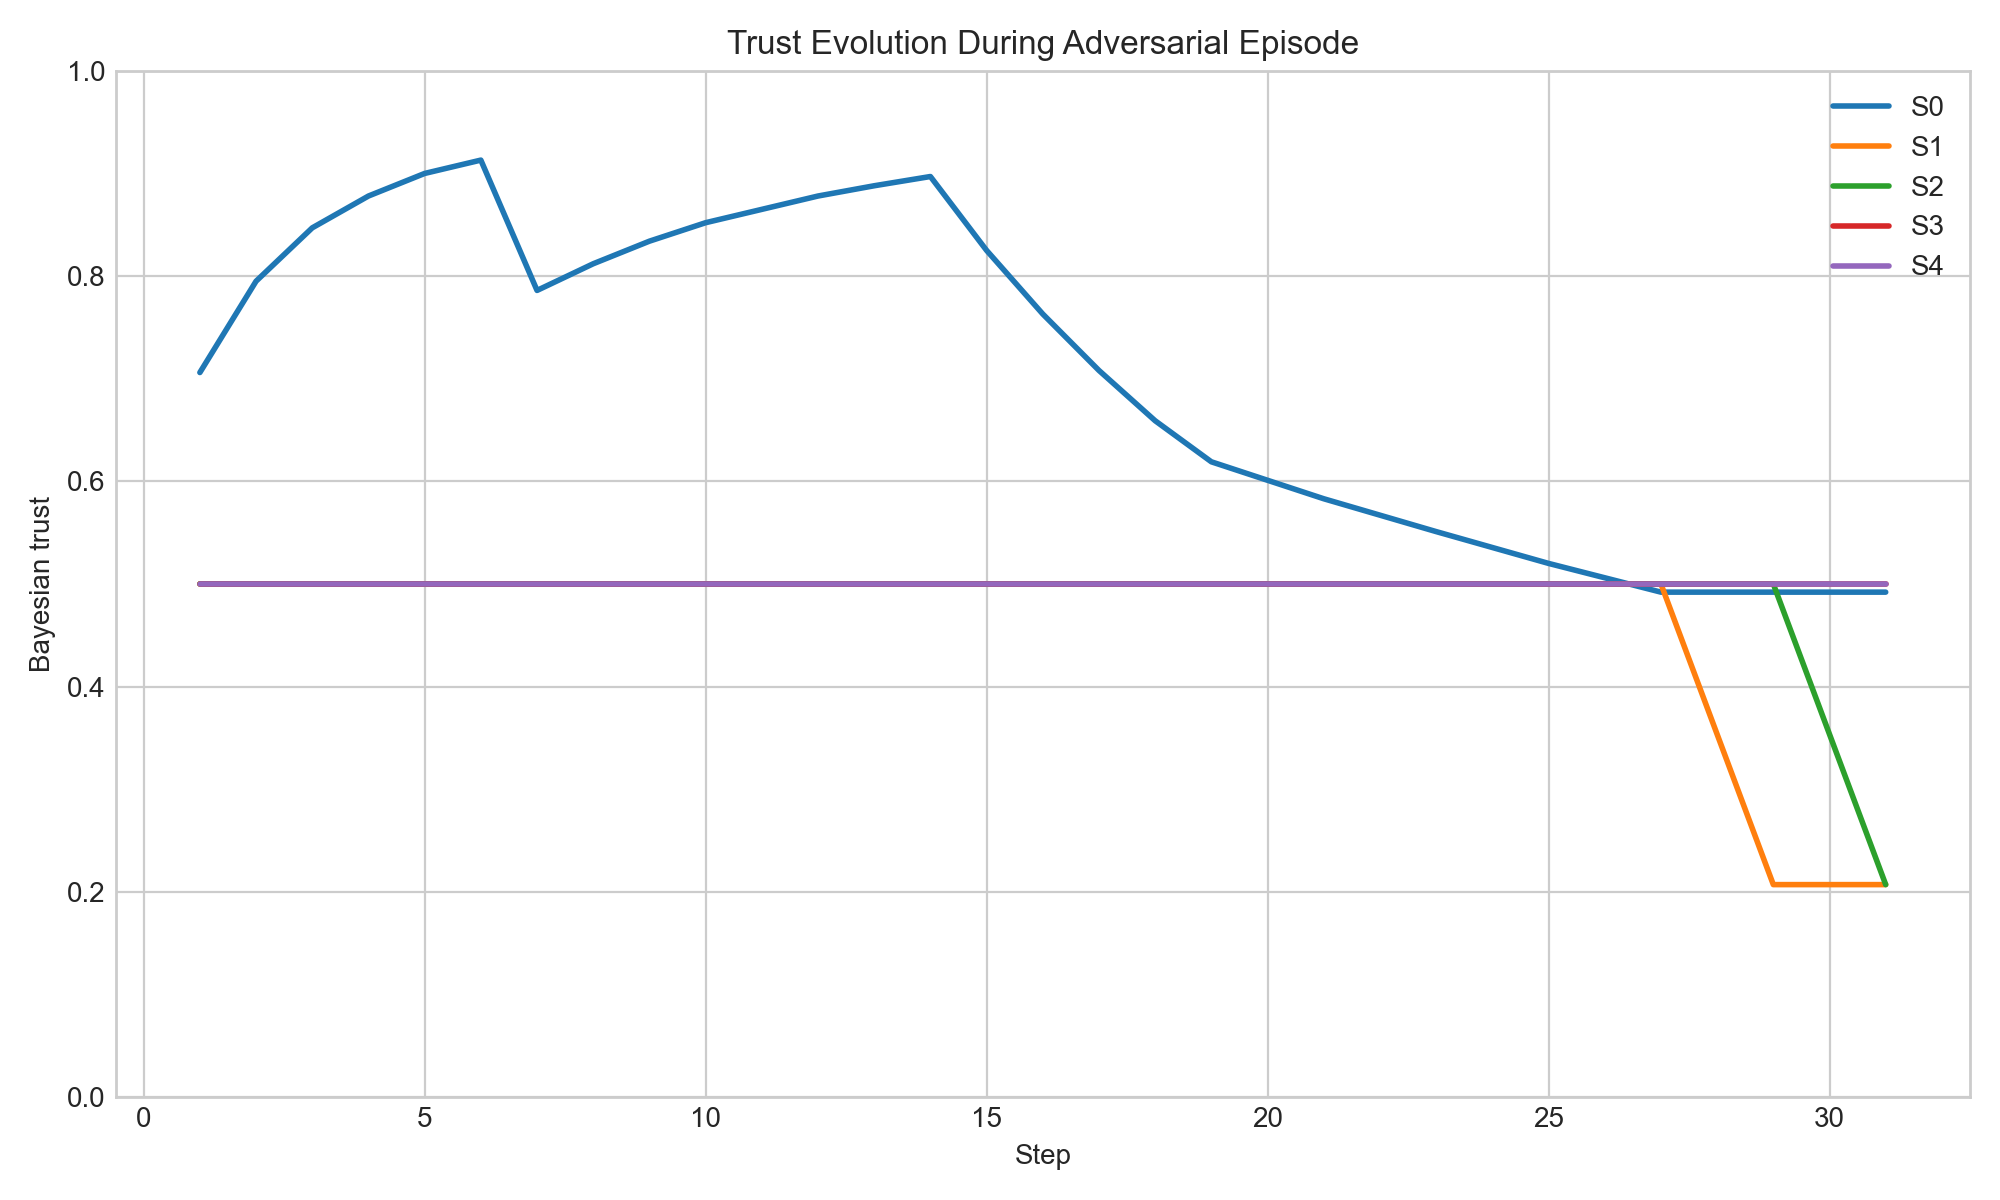

outputs/charts/detection_vs_poisoning.png


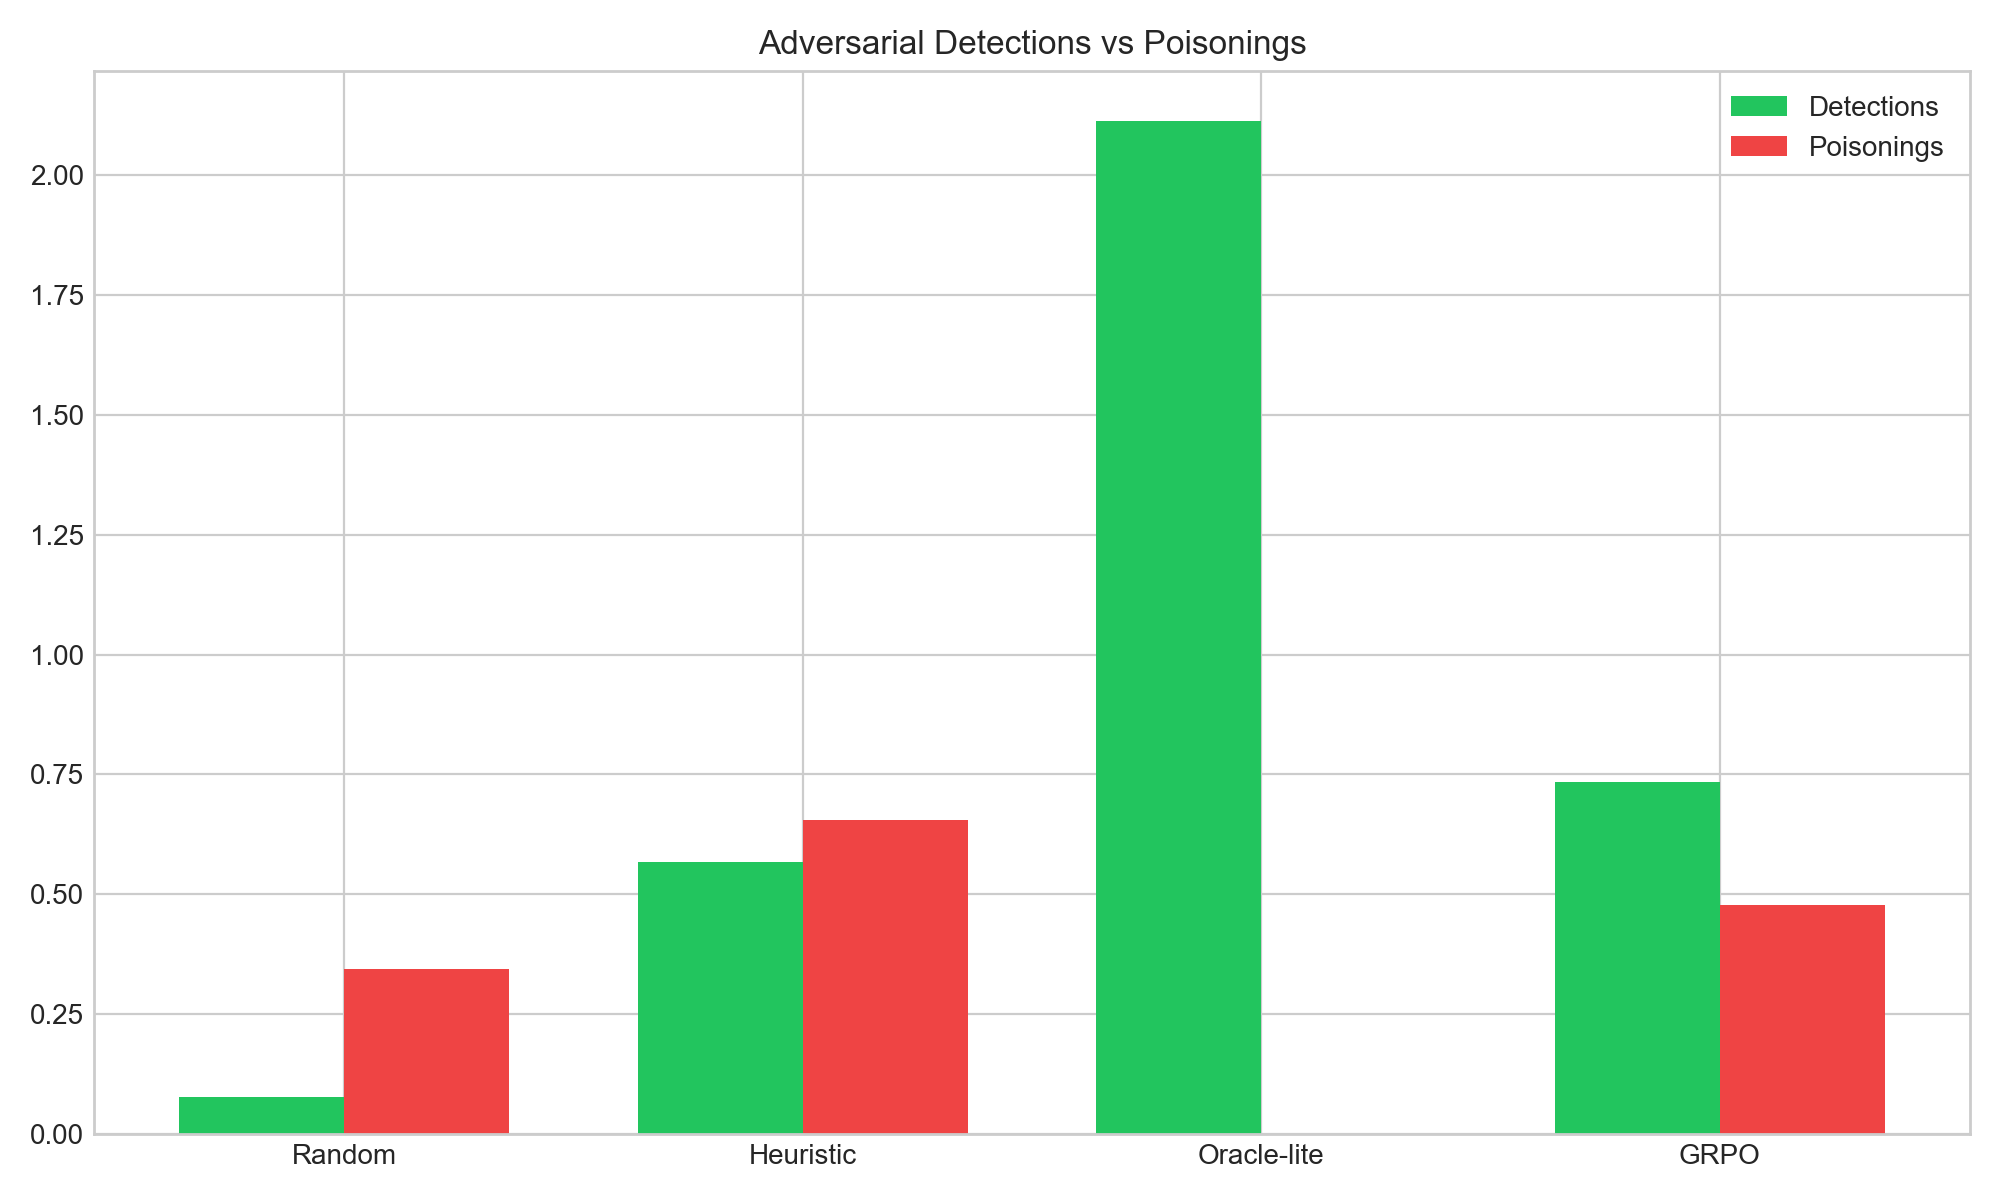

outputs/charts/cluster_health_timeline.png


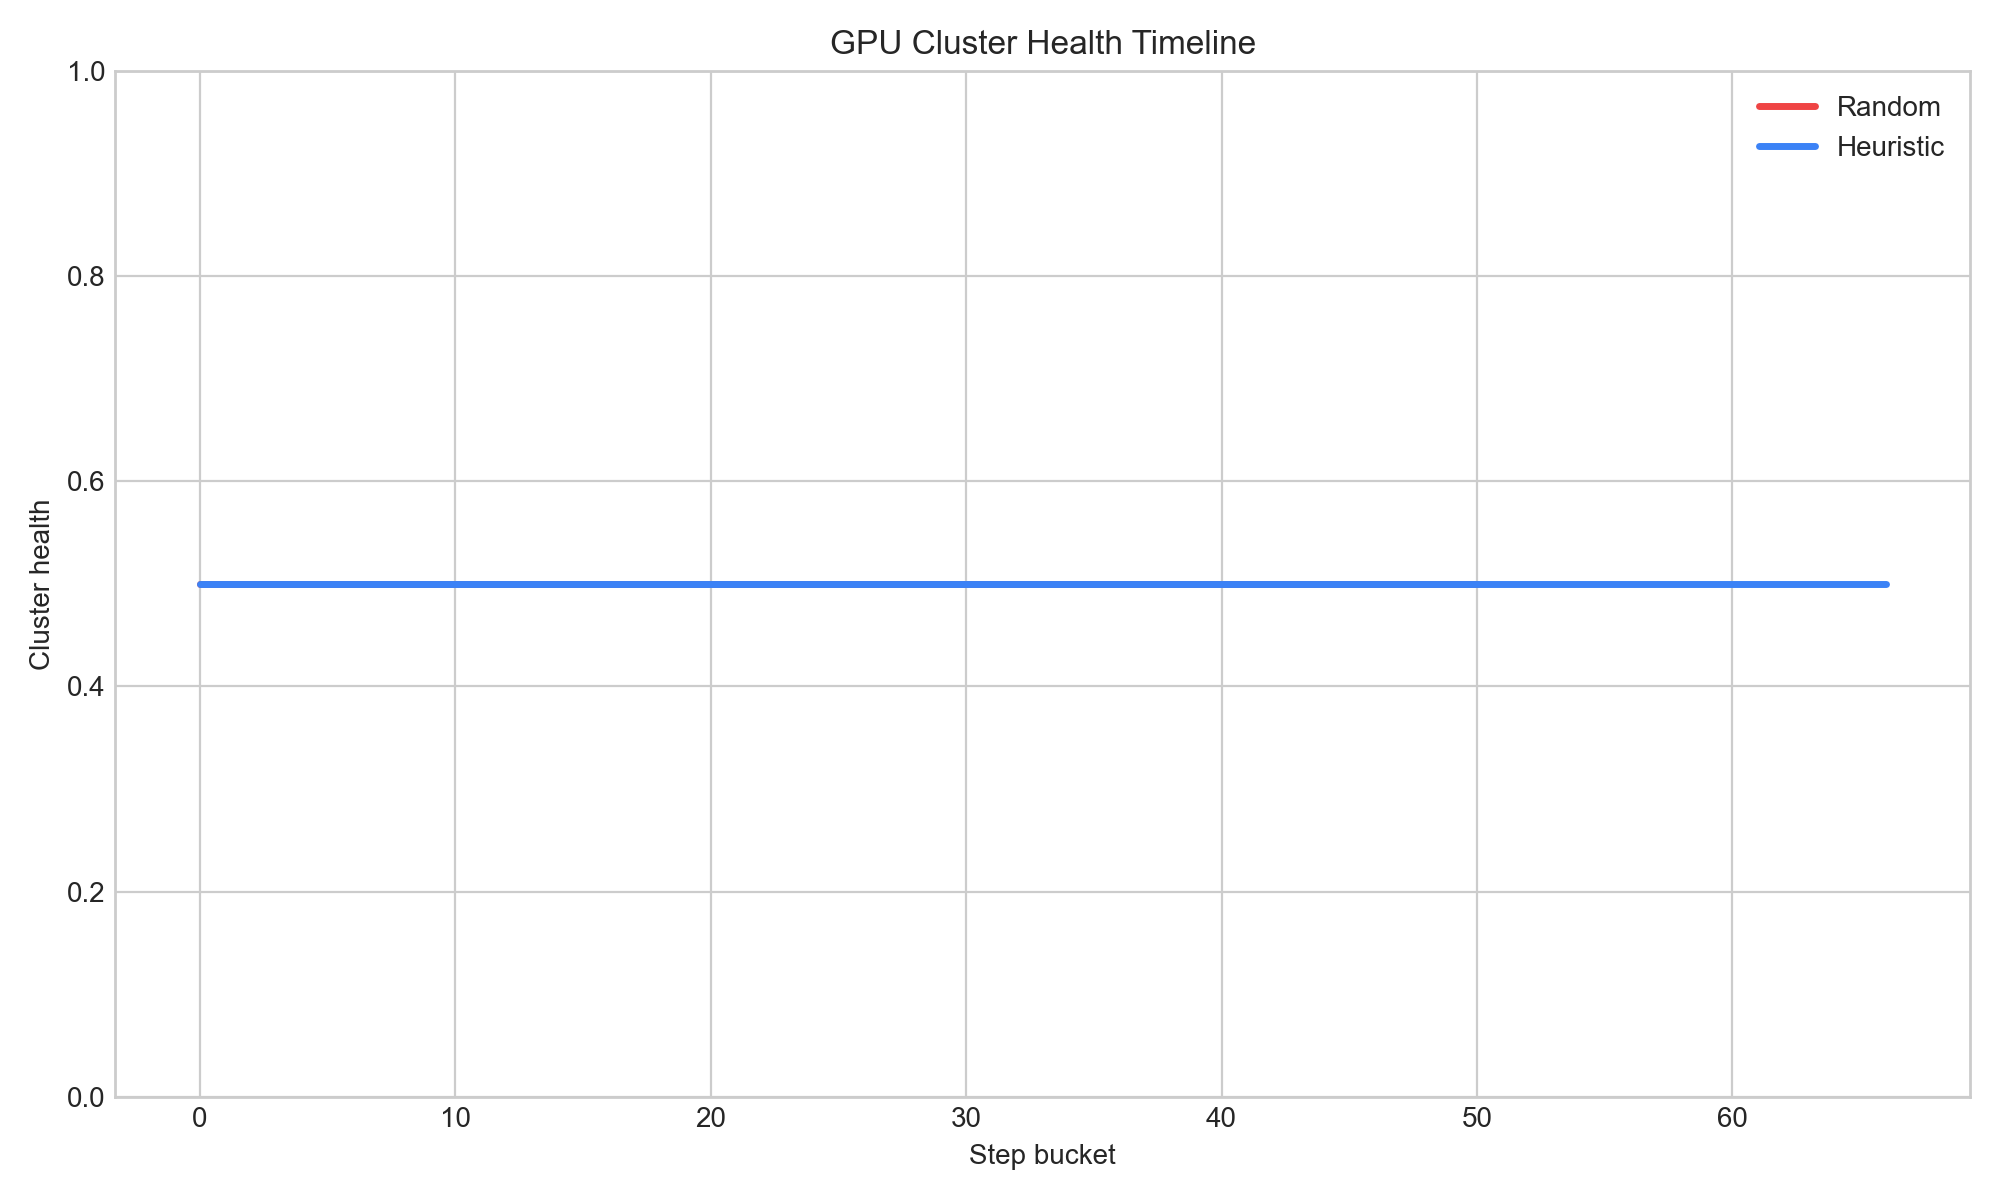

outputs/charts/task_radar.png


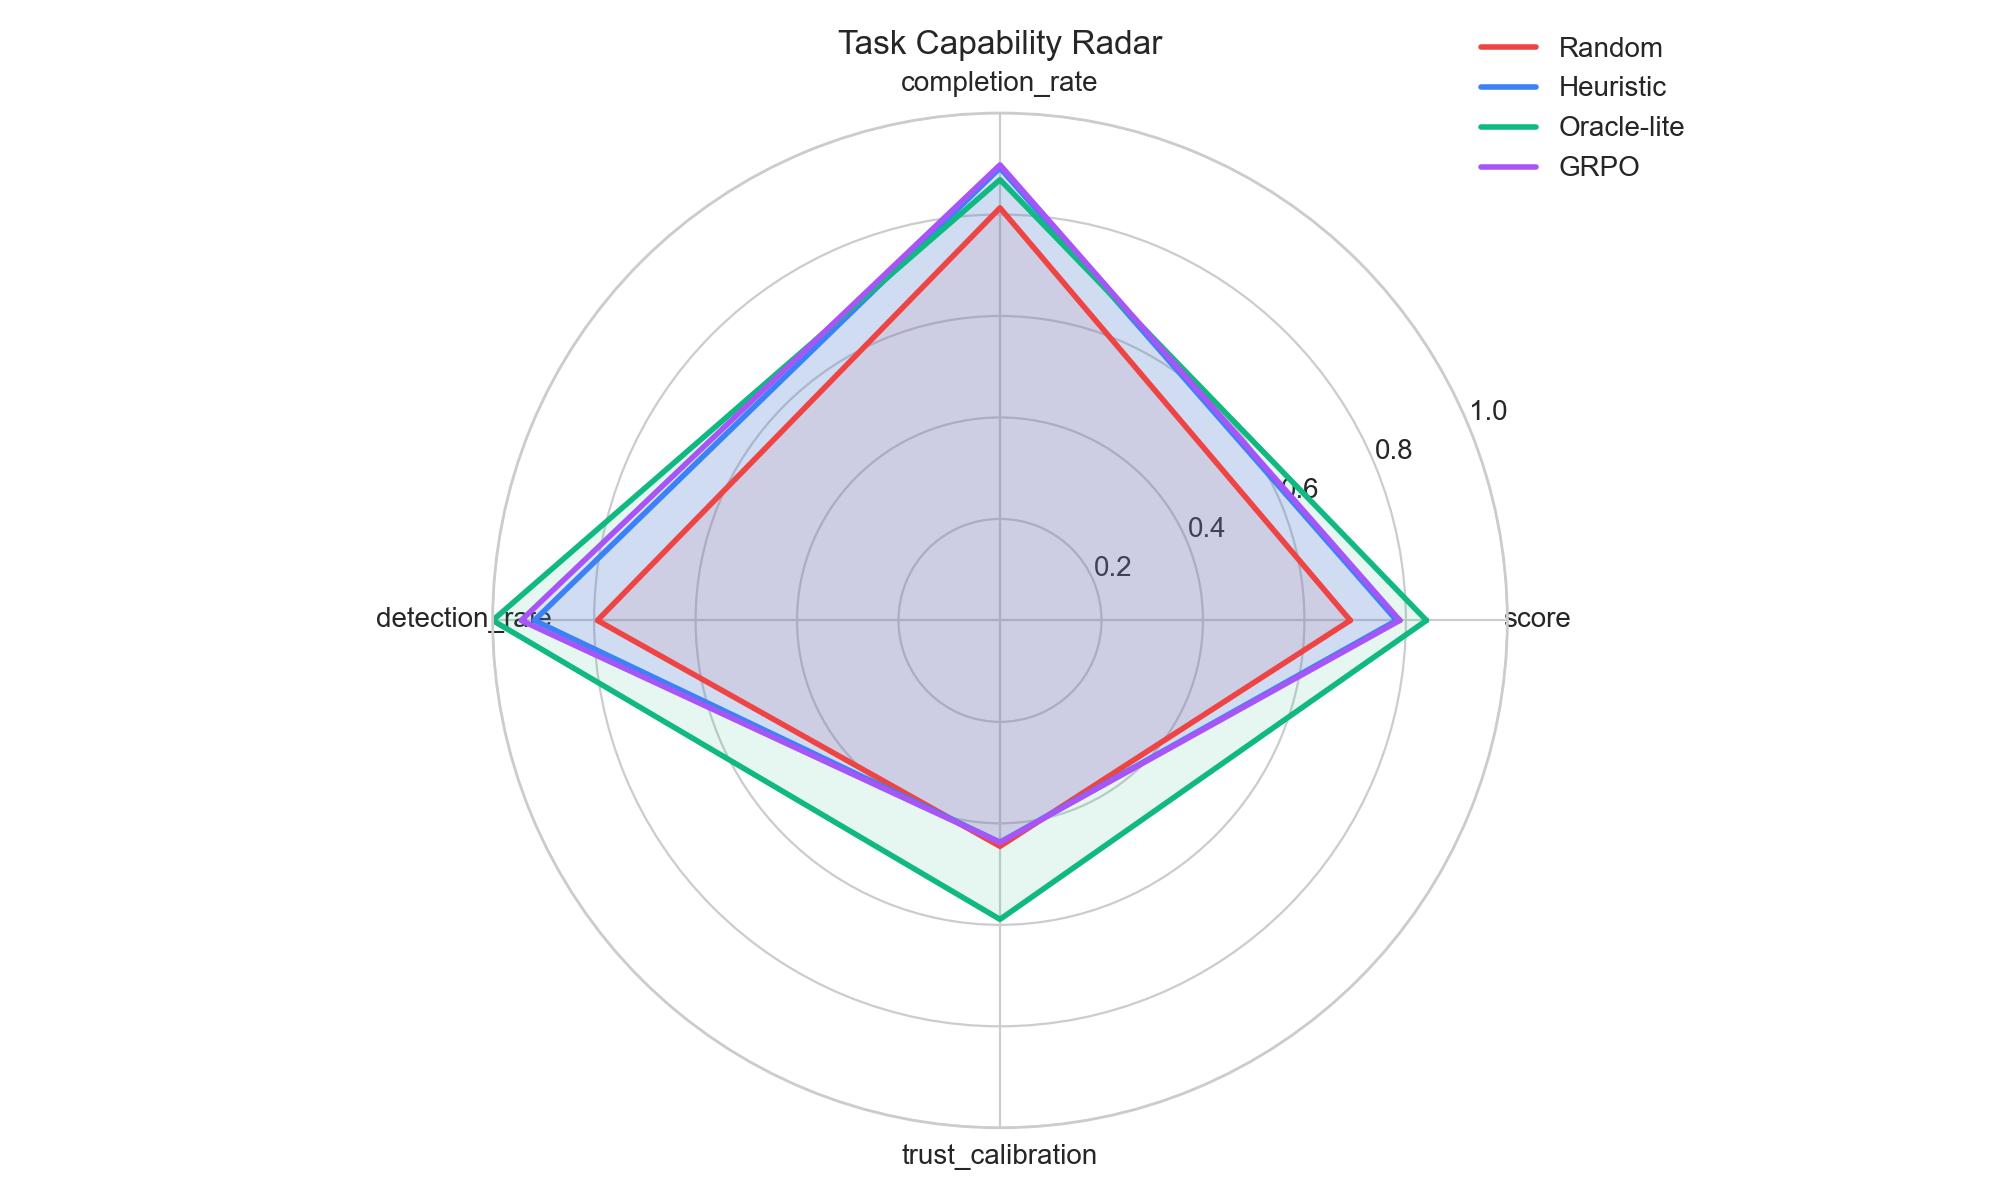

outputs/charts/ablation.png


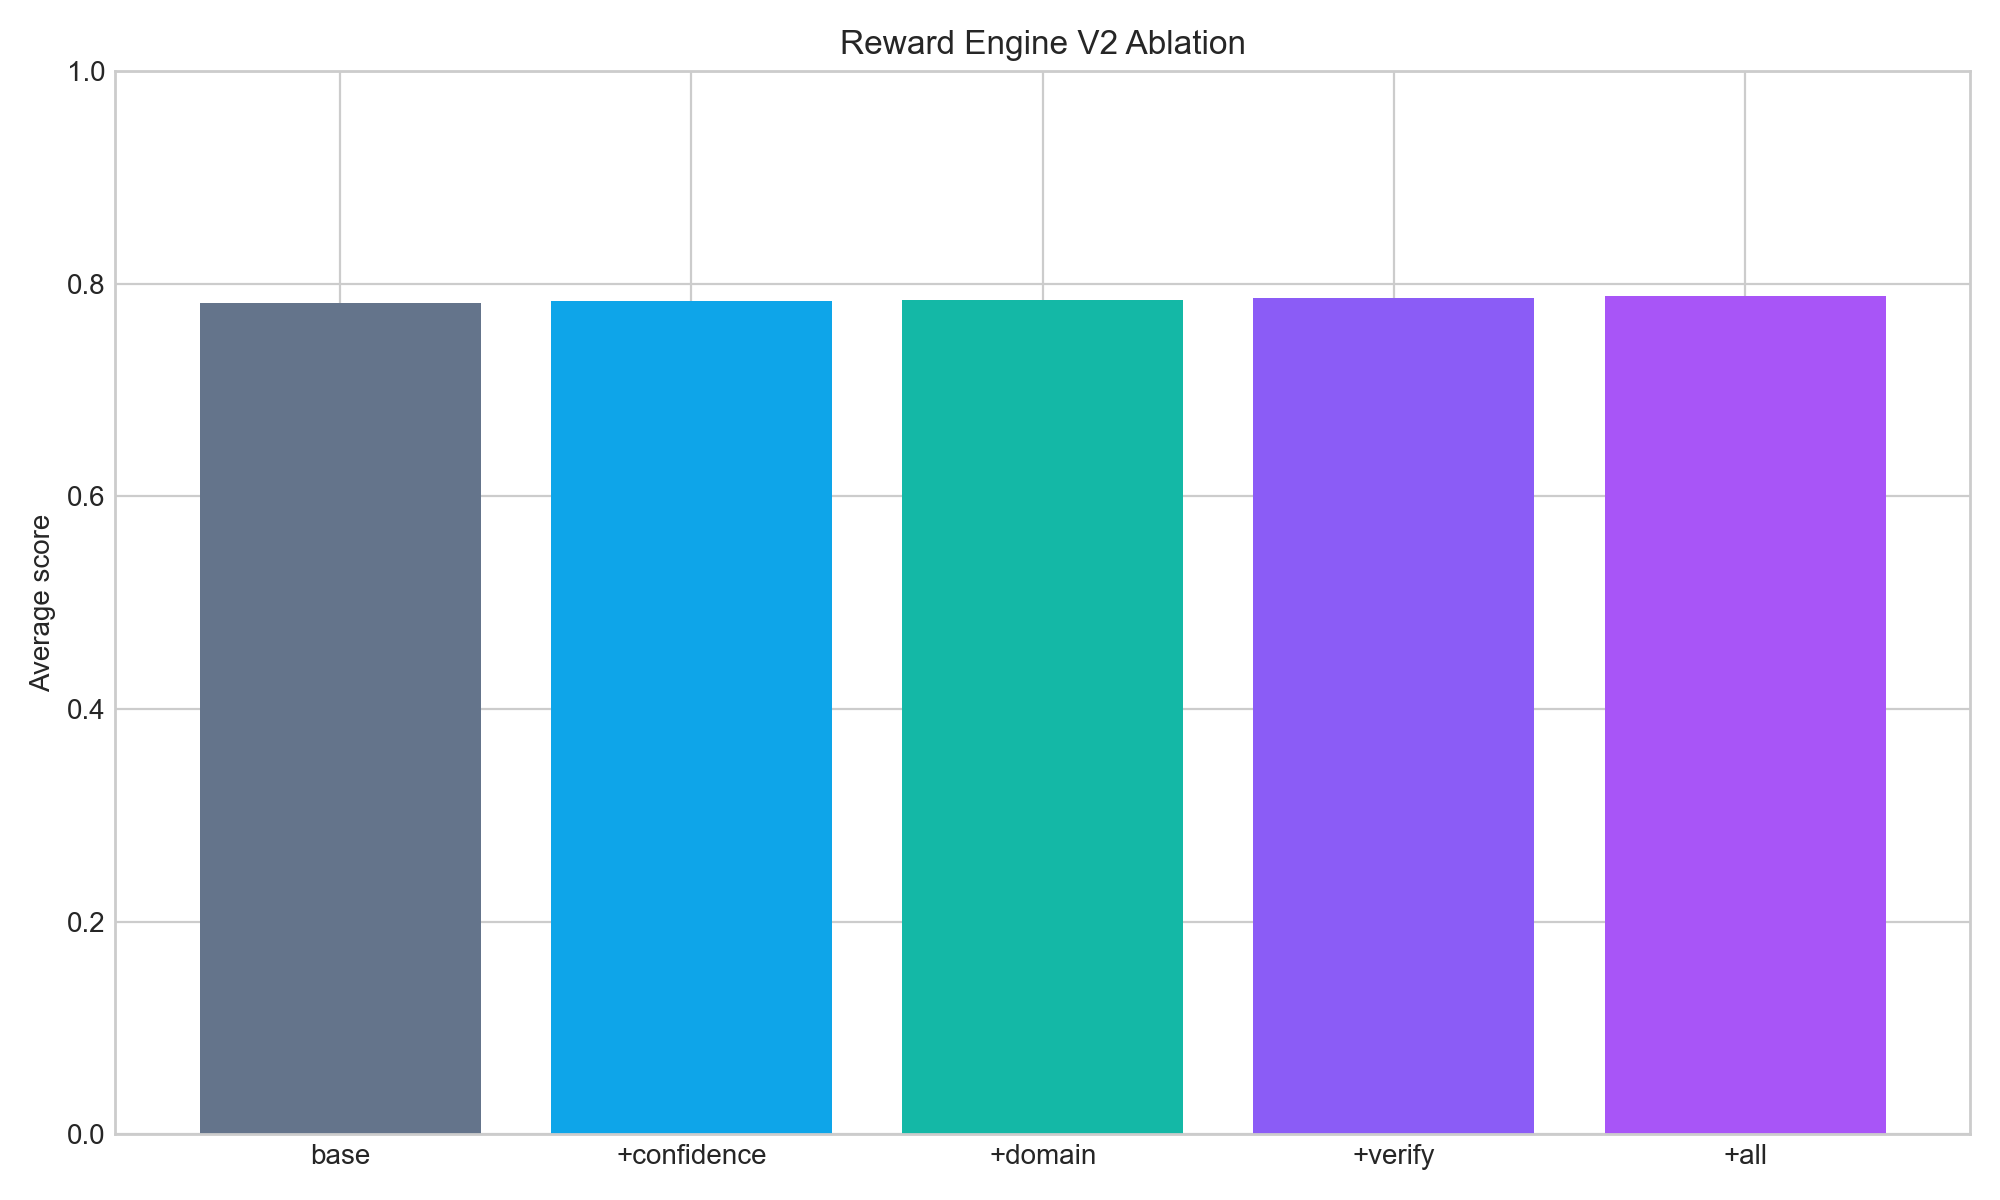

In [9]:
# Cell 11 - Inline preview of the headline charts.
from IPython.display import Image, display

for name in [
    "baseline_grouped_bars.png",
    "grpo_reward_curve.png",
    "trust_evolution.png",
    "detection_vs_poisoning.png",
    "cluster_health_timeline.png",
    "task_radar.png",
    "ablation.png",
]:
    path = f"outputs/charts/{name}"
    print(path)
    display(Image(path))

In [10]:
# Cell 12 - (optional) Push the LoRA adapter and outputs/ to a Hub repo.
# Requires Cell 3 to have authenticated. Change the repo id to your own namespace.
REPO_ID = "XcodeAddy/sentinel-grpo-qwen15"

from huggingface_hub import HfApi
import os

api = HfApi()
api.create_repo(REPO_ID, exist_ok=True)

if os.path.isdir("training/sentinel_qwen15_grpo"):
    api.upload_folder(folder_path="training/sentinel_qwen15_grpo", repo_id=REPO_ID)
else:
    print("No adapter folder; skipping LoRA upload.")

api.upload_folder(
    folder_path="outputs",
    repo_id=REPO_ID,
    path_in_repo="outputs",
    allow_patterns=["*.json", "*.jsonl", "charts/*.png"],
)
print(f"Uploaded artifacts to https://huggingface.co/{REPO_ID}")

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-69edb044-33cd6240674bc18c3f7d34f1;dcb80728-d2bc-4282-9b60-27094a9fe933)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

---

## GO BIG TIER - only run on Pro / L4 / A100

The cell below replaces the smoke run from Cell 5 with a 200-episode GRPO training run. Free T4 is unlikely to finish it in a single Colab session, so prefer Pro/L4 here. After it completes, re-run cells 6, 7, 8, 9, 10, 11 (and optionally 12) in order to refresh every artifact and chart against the better adapter.

In [11]:
# Cell 14 - Real-run GRPO. After this finishes, re-run cells 6 -> 11 (-> 12).
!python training/train.py \
    --episodes 200 --task all --seed 0 \
    --model unsloth/Qwen2.5-1.5B-Instruct \
    --epochs 1 --batch-size 2 --learning-rate 5e-6 \
    --lora-rank 16 --max-seq-length 1024 \
    --output-dir training/sentinel_qwen15_grpo

Training dependencies are not installed locally.
Local check passed. For onsite GPU training run:
  pip install '.[training]'
  python training/train.py --episodes 300 --task all
